# Vertiefung Darstellung von Daten, Datenformat JSON und Web APIs

**Einordnung im Modul:** Datenrepräsentation, Datenformate, Datenquellen:Web APIs, Datenimport

**Kompetenzfokus:** 
- Datenrepräsentation in Python verstehen und nutzen
- Daten aus Web APIs abrufen und in Python verarbeiten
- Daten in JSON-Format verstehen und nutzen
- Datentransformation mit dem Ziel Daten so aufzubereiten, dass sie für weitere Analysen oder Visualisierungen genutzt werden können

## Lernziele 

| Stufe           | Lernziel: Ich kann…                               |
|------------------|----------------------------------------------------|
| 1 Erinnern | die JSON-Datenstruktur definieren und deren typische Merkmale (z.B. Schlüssel-Wert-Paare) benennen. |
| 1 Erinnern | die Funktion und den Zweck von Web-APIs beschreiben. |
| 2 Verstehen | den Aufbau und die Struktur von JSON-Daten erläutern. |
| 2 Verstehen | erklären, wie JSON-Daten mit Python eingelesen, verarbeitet und ausgegeben werden. |
| 2 Verstehen | den Unterschied zwischen json.loads() und json.dumps() sowie json.load() und json.dump() beschreiben. |
| 2 Verstehen | den Zweck von HTTP-Methoden (z.B. GET, POST) im Kontext von Web-APIs erklären. |
| 2 Verstehen | die JSON-Response einer Web-API interpretieren und deren Struktur nachvollziehen. |
| 3 Anwenden | JSON-Daten aus Dateien oder Web-API-Responses einlesen und in Python-Objekte umwandeln. |
| 3 Anwenden | JSON-Daten mithilfe von json.dumps() und json.dump() in Dateien speichern. |
| 3 Anwenden | mithilfe der Bibliothek requests gezielt Daten von einer Web-API abrufen. |
| 3 Anwenden | JSON-Daten nach bestimmten Kriterien filtern und extrahieren. |
| 3 Anwenden | Daten aus API-Responses in Python-Datenstrukturen wie Listen und Dictionaries überführen und weiterverarbeiten. |
| 3 Anwenden | HTTP-Fehlerbehandlung mit requests implementieren (z.B. .status_code prüfen). |
| 4 Analysieren | komplexe JSON-Strukturen (verschachtelte Dictionaries/Listen) analysieren und geeignete Zugriffsstrategien entwickeln. |
| 4 Analysieren | verschiedene API-Endpoints und deren JSON-Responses vergleichen und deren Aufbau bewerten. |
| 4 Analysieren | mögliche Fehlerquellen beim Zugriff auf Web-APIs identifizieren (z.B. fehlerhafte URLs, fehlende Parameter) und geeignete Lösungen entwickeln. |
| 4 Analysieren | JSON-basierte Datenmodelle mit tabellarischen Strukturen vergleichen und deren Vor- und Nachteile bewerten. |

## 1. Einführung
In diesem Arbeitsblatt lernst du die Grundprinzipien der Darstellung von Daten in der Datenorientierten Programmierung kennen. Wir schauen und den Aufbau von JSON-
Daten an und Vertiefen das Thema Web APIs.

## 2. Darstellung von Daten
- Bevor wir uns mit JSON und Web APIs beschäftigen, müssen wir uns zuerst mit der Darstellung von Daten auseinandersetzen. 
- In der Datenorientierten Programmierung, werden Daten von Funktionalitäten getrennt.
- Die Empfehlung hier ist die Daten in Datensätzen zu organisieren. 
- Die Datensätze sollen möglichst in generischen Formaten dargestellt werden, damit sie von verschiedenen Programmen und Systemen gelesen und verarbeitet werden können. 
- Flexibilität und Generizität sind hier die Schlüsselwörter.
- Schauen wir uns ein Beispiel eines Datenentitätsdiagramm (ähnlich der Klassendiagramm in der OOP). 
- Beim Beispiel handelt es sich um ein Datenmodell für eine Bibliothek.

![Library management relation model_Data-Oriented_Programming_Y.Sharvit_2022.jpg](Library%20management%20relation%20model_Data-Oriented_Programming_Y.Sharvit_2022.jpg )

Library management relation model - Data-Oriented_Programming, Y.Sharvit 2022


In unserem Datenentitätsdiagramm sehen wir drei Arten von Datenaggregationen:

![The building blocks model_Data-Oriented_Programming_Y.Sharvit_2022.jpg](The%20building%20blocks%20model_Data-Oriented_Programming_Y.Sharvit_2022.jpg)

The building blocks model - Data-Oriented_Programming, Y.Sharvit 2022


### Datensatz (Record)
- Ein Datensatz ist eine Sammlung von heterogenen Daten, die zu einem bestimmten Thema gehören. 
- Ein Datensatz kann aus einer oder mehreren Eigenschaften bestehen. 
- Ein Beispiel für einen Datensatz ist ein Eintrag eines Buches in einer Bibliothek. 
- Ein Eintrag in einem Buch enthält Informationen wie den ISBN-Code, den Titel, die Autoren, das Erscheinungsjahr und eine Liste der Exemplare des Buches in der Bibliothek. 
- Ein weiteres Beispiel für einen Datensatz ist die Bibliothek selbst oder auch der Katalog.

### Sammlung von Daten (Collection)
- Eine Collection ist eine Sammlung von Informationen gleicher Art. 
- Die Position einzelner Infos in der Sammlung ist nicht wichtig. (List, Array, LinkedList,Set, etc.)
- Ein Beispiel für eine Collection in der oberen Abbildung ist die Liste der Autoren eines Buches oder die Lister der Exemplare eines Buches (bookItems) in der Bibliothek.

### Index
- Ein Index ist eine Datenstruktur von homogenen Daten. 
- Wie der booksByIsbn oder authorsById im Katalog, welches eine Sammlung von Büchern bzw. Autoren ist, die nach ISBN-Code bzw. id des Autors indexiert sind.

Schauen wir uns eine Instanz eines Buches in der Bibliothek an.

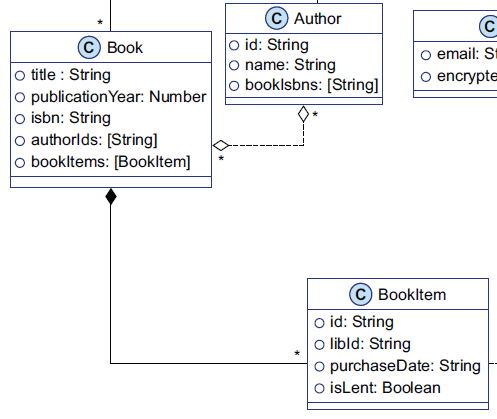

In [91]:
watchmenBook = {
    "title": "Watchmen",
    "publicationYear": 1987,
    "isbn": "978-1779501127",
    "authorIds": ["alan-moore", "dave-gibbons"],
    "bookItems": [
        {
            "id": "book-item-1",
            "libId": "nyc-central-lib",
            "purchaseDate": "2024-01-01",
            "isLent": False,
        },
        {
            "id": "book-item-2",
            "libId": "nyc-central-lib",
            "purchaseDate": "2024-01-01",
            "isLent": False,
        },
    ],
}

## 3. Datenobjekt JSON
- JSON steht für JavaScript Object Notation und ist ein leichtgewichtiges Datenaustauschformat. 
- Es ist einfach zu lesen und zu schreiben und wird von vielen Programmiersprachen einschliesslich Python unterstützt.
- In Python kann man JSON-Dateien mit der integrierten JSON-Bibliothek lesen und schreiben. 
- json.load(): Wird verwendet, um ein JSON-Dokument aus einer Datei oder einem Datei-ähnlichen Objekt (das heisst einem Objekt mit einer read()-Methode, wie ein Dateiobjekt) zu lesen und in ein Python-Objekt zu konvertieren.
- json.loads(): Steht für "load string" und wird verwendet, um ein JSON-Dokument aus einem String zu lesen und in ein Python-Objekt zu konvertieren. Das ist hilfreich, wenn Sie JSON-Daten aus einer Quelle haben, die bereits als String vorliegt.
- json.dump(): Wird verwendet, um ein Python-Objekt in ein JSON-kodiertes Datei-ähnliches Objekt (also ein Objekt mit einer write()-Methode) zu schreiben. Es wird häufig genutzt, um Daten in eine Datei zu schreiben.
- json.dumps(): Steht für "dump string" und wird verwendet, um ein Python-Objekt in einen JSON-kodierten String zu konvertieren. Dies ist nützlich, wenn Sie das JSON als String speichern oder über das Netzwerk senden möchten.
- Link zur Dokumentation: (https://www.json.org/json-de.html)
- In einem JSON-Dokument können wir Datensätze, Sammlungen und Indexe darstellen.
- In einem Beispiel unter "library_data.json" sehen wir ein JSON-Dokument, das die Daten der Bibliothek darstellt.

Schauen wir gemeinsam ein kleines Beispiel einer JSON-Datei an. Weiter schauen wir uns an, wie wir die Daten in Python lesen und schreiben können.

1. Datei "library_data.json" anschauen.
2. Versuchen wir in Python die Datei zu lesen
3. Versuchen wir die Daten zu manipulieren
4. Versuchen wir die Daten zu schreiben

In [93]:
import json

# Laden der Bibliotheksdaten aus der Datei library_data.json
with open("library_data.json", "r") as file:
    data = json.load(file)

import pprint


pprint.pprint(data)

{'Library': {'Catalog': {'authorsById': {'author-1': {'bookIsbns': ['978-3-16-148410-0'],
                                                      'id': 'author-1',
                                                      'name': 'John Doe'},
                                         'author-2': {'bookIsbns': ['978-3-16-148410-0'],
                                                      'id': 'author-2',
                                                      'name': 'John Doe'}},
                         'booksByIsbn': {'978-3-16-148410-0': {'authorIds': ['author-1',
                                                                             'author-2'],
                                                               'bookItems': [{'id': 'bookitem-1',
                                                                              'isLent': True,
                                                                              'libId': 'nyc-central-lib',
                                                

In [95]:
# Zugriff auf das Katalog-Objekt
catalog = data["Library"]["Catalog"]
pprint.pprint(catalog)

{'authorsById': {'author-1': {'bookIsbns': ['978-3-16-148410-0'],
                              'id': 'author-1',
                              'name': 'John Doe'},
                 'author-2': {'bookIsbns': ['978-3-16-148410-0'],
                              'id': 'author-2',
                              'name': 'John Doe'}},
 'booksByIsbn': {'978-3-16-148410-0': {'authorIds': ['author-1', 'author-2'],
                                       'bookItems': [{'id': 'bookitem-1',
                                                      'isLent': True,
                                                      'libId': 'nyc-central-lib',
                                                      'purchaseDate': '2020-01-01'},
                                                     {'id': 'bookitem-2',
                                                      'isLent': True,
                                                      'libId': 'nyc-central-lib',
                                                      

In [96]:
# Hinzufügen eines Buches zum Katalog
def addNewBookWithBookItemsAndAuthors(catalog, book):
    if "booksByIsbn" not in catalog:
        catalog["booksByIsbn"] = {}
    if "authorsById" not in catalog:
        catalog["authorsById"] = {}

    if book["isbn"] not in catalog["booksByIsbn"]:
        catalog["booksByIsbn"][book["isbn"]] = book

    for author in book["authorIds"]:
        if author not in catalog["authorsById"]:
            catalog["authorsById"][author] = {
                "id": author,
                "name": author,
                "bookIsbns": [book["isbn"]],
            }
        else:
            catalog["authorsById"][author]["bookIsbns"].append(book["isbn"])

    return catalog


addNewBookWithBookItemsAndAuthors(catalog, watchmenBook)

{'booksByIsbn': {'978-3-16-148410-0': {'title': 'Example Book Title',
   'publicationYear': 2021,
   'isbn': '978-3-16-148410-0',
   'authorIds': ['author-1', 'author-2'],
   'bookItems': [{'id': 'bookitem-1',
     'libId': 'nyc-central-lib',
     'purchaseDate': '2020-01-01',
     'isLent': True},
    {'id': 'bookitem-2',
     'libId': 'nyc-central-lib',
     'purchaseDate': '2020-01-01',
     'isLent': True}]},
  '978-1779501127': {'title': 'Watchmen',
   'publicationYear': 1987,
   'isbn': '978-1779501127',
   'authorIds': ['alan-moore', 'dave-gibbons'],
   'bookItems': [{'id': 'book-item-1',
     'libId': 'nyc-central-lib',
     'purchaseDate': '2024-01-01',
     'isLent': False},
    {'id': 'book-item-2',
     'libId': 'nyc-central-lib',
     'purchaseDate': '2024-01-01',
     'isLent': False}]}},
 'authorsById': {'author-1': {'id': 'author-1',
   'name': 'John Doe',
   'bookIsbns': ['978-3-16-148410-0']},
  'author-2': {'id': 'author-2',
   'name': 'John Doe',
   'bookIsbns': ['9

In [97]:
# Dumpen der Daten in die Datei library_data_new.json
with open("library_data_new.json", "w") as file:
    json.dump(data, file, indent=4)

## 4. Datenquelle Web-API's
- Eine Web-API (Application Programming Interface) ist ein Programmierschnittstelle, die es Anwendungen erlaubt, miteinander zu kommunizieren und Daten auszutauschen. 
- Web-APIs ermöglichen es, dass verschiedene Anwendungen, die auf unterschiedlichen Plattformen und Geräten laufen, miteinander interagieren können.
- Eine Möglichkeit, Web-APIs in Python zu nutzen, besteht darin, die eingebauten HTTP-Methoden von Python zu verwenden, um Daten von einer Web-API abzurufen oder an eine Web-API zu senden.
- Das "requests"-Modul von Python ist eine Bibliothek, die genutzt wird, um HTTP-Anfragen an eine Web-API zu senden und die erhaltenen Antworten zu verarbeiten.
- Das "requests"-Modul ist nicht in der Standardbibliothek von Python enthalten, aber es kann mit dem Befehl "pip install requests" installiert werden.
- requests.get(): Wird verwendet, um eine HTTP-GET-Anfrage an eine Web-API zu senden und die Antwort zu erhalten.
- requests.post(): Wird verwendet, um eine HTTP-POST-Anfrage an eine Web-API zu senden und die Antwort zu erhalten.
- Manche Web-APIs benötigen eine Authentifizierung, um auf die Daten zuzugreifen. 
- In diesem Fall müssen wir die Anmeldeinformationen in der Anfrage senden.
- Unterschied zwischen GET und POST ist die Art der Anfrage. GET-Anfragen werden verwendet, um Daten von einer Web-API abzurufen, während POST-Anfragen verwendet werden, um Daten an eine Web-API zu senden. GET-Anfragen sind in der Regel sicherer und schneller als POST-Anfragen, da sie keine Daten senden und daher keine Auswirkungen auf die Daten haben. POST-Anfragen können jedoch mehr Daten senden und sind daher flexibler als GET-Anfragen.

Schauen wir uns gemeinsam zwei Web-API Beispiele an.
- Bei der einen API handelt es sich um eine Wetter-API Namens "OpenWeatherMap"[https://openweathermap.org/full-price]. 
- Bei der anderen API handelt es sich um eine von der U.S. Department of Agriculture API Namens "FoodData Central"[https://fdc.nal.usda.gov/food-search].

#### 1. Beispiel: OpenWeatherMap API

- Frage mit der "request"-Library die Wetterdaten von einer Stadt von der Webseite "https://openweathermap.org" an.
- Printe im Code das Land in dem sich die Stadt befindet, sowie die momentane Temperatur, Windstärke und Feuchtigkeit. 


In [ ]:
import requests

# API-Key
api_key = "EIGENER_API_KEY_HIER_EINFÜGEN"

# Stadt
city = "Zürich"
country = "CH"

# Geodaten URL
url_geo = f"http://api.openweathermap.org/geo/1.0/direct?q={
    city},{country}&limit=5&appid={api_key}"

# Anfrage an die API
content_geo = requests.get(url_geo)

# Überprüfen des Statuscodes
if content_geo.status_code == 200:
    data_geo = content_geo.json()
else:
    print(f"Fehler bei der Anfrage: {content_geo.status_code}")

# Ausgabe der Geodaten
import pprint

pprint.pprint(data_geo)

[{'country': 'CH',
  'lat': 47.3744489,
  'local_names': {'af': 'Zürich',
                  'am': 'ዙሪክ',
                  'an': 'Zúrich',
                  'ar': 'زيورخ',
                  'az': 'Sürix',
                  'be': 'Цюрых',
                  'bg': 'Цюрих',
                  'bn': 'জুরিখ',
                  'br': 'Zürich',
                  'bs': 'Zürich',
                  'ca': 'Zuric',
                  'cs': 'Curych',
                  'cv': 'Цюрих',
                  'cy': 'Zürich',
                  'da': 'Zürich',
                  'de': 'Zürich',
                  'el': 'Ζυρίχη',
                  'en': 'Zurich',
                  'eo': 'Zuriko',
                  'es': 'Zúrich',
                  'et': 'Zürich',
                  'eu': 'Zürich',
                  'fa': 'زوریخ',
                  'fi': 'Zürich',
                  'fr': 'Zurich',
                  'ga': 'Zürich',
                  'gd': 'Zürich',
                  'gl': 'Zúric',
                  'h

In [99]:
# Latitude und Longitude extrahieren
lat = data_geo[0]["lat"]
lon = data_geo[0]["lon"]

# Wetterdaten URL
url_weather = f"https://api.openweathermap.org/data/2.5/weather?lat={
    lat}&lon={lon}&appid={api_key}"

# Anfrage an die API
content_weather = requests.get(url_weather)

# Umwandeln der Antwort in ein JSON-Objekt
if content_weather.status_code == 200:
    data_weather = content_weather.json()
else:
    print(f"Fehler bei der Anfrage: {content_weather.status_code}")

# Ausgabe der Wetterdaten
pprint.pprint(data_weather)

{'base': 'stations',
 'clouds': {'all': 0},
 'cod': 200,
 'coord': {'lat': 47.3744, 'lon': 8.541},
 'dt': 1773960878,
 'id': 6458798,
 'main': {'feels_like': 273.64,
          'grnd_level': 961,
          'humidity': 77,
          'pressure': 1020,
          'sea_level': 1020,
          'temp': 276.17,
          'temp_max': 277.2,
          'temp_min': 275.32},
 'name': 'Zürich District',
 'sys': {'country': 'CH',
         'id': 6932,
         'sunrise': 1773898281,
         'sunset': 1773941759,
         'type': 1},
 'timezone': 3600,
 'visibility': 10000,
 'weather': [{'description': 'clear sky',
              'icon': '01n',
              'id': 800,
              'main': 'Clear'}],
 'wind': {'deg': 20, 'speed': 2.57}}


In [104]:
# Extrahieren der Wetterdaten
country = data_weather["sys"]["country"]
windspeed = data_weather["wind"]["speed"]
temp = data_weather["main"]["temp"]
humidity = data_weather["main"]["humidity"]


# Funktion zur Umrechnung von Kelvin in Celsius
def kelvin_to_celsius(temp):
    return round(temp - 273.15, 1)


# Ausgabe der Wetterdaten
print(
    f"{city} ist eine Stadt in {country}. Die Temperatur beträgt aktuell {
      kelvin_to_celsius(temp)}°C. Die Windgeschwindigkeit beträgt {windspeed} m/s und die relative Luftfeuchtigkeit {humidity}%."
)

Zürich ist eine Stadt in CH. Die Temperatur beträgt aktuell 3.0°C. Die Windgeschwindigkeit beträgt 2.57 m/s und die relative Luftfeuchtigkeit 77%.


#### 2. Beispiel: FoodData Central API

Die Firma, die LeckerLunch GmbH, stellt Mittagsmenüs her und liefert diese als Caterer an dritte Firmen aus. Nun werden von einzelnen Firmen die Nährwertangaben zu den einzelnen Menüs gefordert. Wir als Unternehmen möchten uns nicht mit der Pflege der Nährwertangaben auf unseren Rohstoffen kümmern müssen. Daher möchten wir die Nährwertangaben aus anderen vertraulichen Quellen beziehen.

U.S. Department of Agriculture API Namens "FoodData Central"[https://fdc.nal.usda.gov/food-search]

Schreibt bitte ein Code, welches zu unseren Rezepten die Nährwertangaben berechnet. Als erstes Beispiel zu unserem Menü Poulet-Curry mit Reis. Die Rezeptangaben sind für 4 Personen.

In [108]:
# Bestandteile des Menüs
menu_composition = ["Chicken-Curry", "Rice"]


# Zutaten des Rezepts sind die folgenden. Rezepte sind immer für 4 Personen und Mengenangaben in Gramm
recipes = {
    "Chicken-Curry": [
        {"name": "chicken breast", "qty": 500},
        {"name": "coconut milk", "qty": 400},
        {"name": "pepper red", "qty": 100},
        {"name": "onion", "qty": 100},
        {"name": "garlic", "qty": 10},
        {"name": "curry paste", "qty": 20},
        {"name": "olive oil", "qty": 15},
    ],
    "Rice": [
        {"name": "rice", "qty": 200},
        {"name": "butter", "qty": 20},
        {"name": "salt", "qty": 3},
        {"name": "olive oil", "qty": 15},
    ],
    "Bolognese": [
        {"name": "ground beef chuck", "qty": 300},
        {"name": "celery", "qty": 100},
        {"name": "onion", "qty": 50},
    ],
}


# Zielbild

# {'chicken breast': 500,
#  'coconut milk': 400,
#  'pepper red': 100,
#  'onion': 100,
#  'garlic': 10,
#  'curry paste': 20,
#  'olive oil': 30,
#  'rice': 200,
#  'butter': 20,
#  'salt': 3}


# Folgende Ausgabe wird erwartet

# Das Menü Poulet-Curry mit Reis für 4 Personen hat die folgenden Nährwertangaben

# calories 2258.58 kcal
# fat 135.57 g

# carbohydrate 92.84 g

# protein 172.41 g

**1.Schritt**
Summiere alle Zutaten auf menu_composition Liste

In [109]:
# Summiere alle Zutaten auf menu_composition Liste

menu_ingredients = {}
for dish in menu_composition:
    for ingredient in recipes[dish]:
        if ingredient["name"] in menu_ingredients:
            menu_ingredients[ingredient["name"]] += ingredient["qty"]
        else:
            menu_ingredients[ingredient["name"]] = ingredient["qty"]


menu_ingredients

{'chicken breast': 500,
 'coconut milk': 400,
 'pepper red': 100,
 'onion': 100,
 'garlic': 10,
 'curry paste': 20,
 'olive oil': 30,
 'rice': 200,
 'butter': 20,
 'salt': 3}

**2.Schritt**
Einbinden der Web-API
Abfragen nach Nährwertdaten & Zusammenstellen der Nährwertinformation

In [ ]:
import requests

API_KEY = "EIGENER_API_KEY_HIER_EINFÜGEN"

SEARCH_URL = "https://api.nal.usda.gov/fdc/v1/foods/search"
DETAIL_URL = "https://api.nal.usda.gov/fdc/v1/food"


def get_food_fdc_id(ingredient):
    """
    Sucht ein Lebensmittel bei USDA und gibt die fdcId des besten Treffers zurück.
    """
    payload = {"query": ingredient, "dataType": ["Foundation"], "pageSize": 1}

    response = requests.post(SEARCH_URL, params={"api_key": API_KEY}, json=payload)
    response.raise_for_status()

    data = response.json()

    if not data.get("foods"):
        raise ValueError(f"Kein Treffer für Zutat gefunden: {ingredient}")

    return data["foods"][0]["fdcId"]


def fetch_food_data(fdc_id):
    """
    Holt die vollständigen USDA-Daten zu einem Lebensmittel.
    Es werden bewusst keine einzelnen Nährstoffe eingeschränkt.
    """
    response = requests.get(f"{DETAIL_URL}/{fdc_id}", params={"api_key": API_KEY})
    response.raise_for_status()
    return response.json()


def extract_all_nutrients(food_data):
    """
    Extrahiert alle verfügbaren Nährstoffe aus der USDA-Antwort.

    Rückgabeformat:
    {
        "Protein": {"amount": 22.525, "unit": "g"},
        "Water": {"amount": 74.78, "unit": "g"},
        ...
    }
    """
    nutrients = {}

    for entry in food_data.get("foodNutrients", []):
        nutrient_info = entry.get("nutrient", {})
        name = nutrient_info.get("name")
        unit = nutrient_info.get("unitName")
        amount = entry.get("amount")

        # Nur echte Nährstoffe mit Zahlenwert übernehmen
        if name is not None and amount is not None:
            nutrients[name] = {"amount": amount, "unit": unit}

    return nutrients


def get_nutrition_data(ingredient):
    """
    Holt alle Nährstoffe eines Lebensmittels.
    """
    fdc_id = get_food_fdc_id(ingredient)
    food_data = fetch_food_data(fdc_id)
    return extract_all_nutrients(food_data), fdc_id


def add_nutrition_data_to_recipe(ingredient, qty):
    """
    Holt alle Basis-Nährstoffe und skaliert sie auf die gewünschte Menge.
    """
    base_nutrition, fdc_id = get_nutrition_data(ingredient)
    return {
        "name": ingredient,
        "fdc_id": fdc_id,
        "qty": qty,
        "nutrients": base_nutrition,
    }


menu_ingredients_with_nutritiondata = [
    add_nutrition_data_to_recipe(ingredient, qty)
    for ingredient, qty in menu_ingredients.items()
]

In [111]:
pprint.pprint(menu_ingredients_with_nutritiondata)

[{'fdc_id': 2646170,
  'name': 'chicken breast',
  'nutrients': {'Ash': {'amount': 1.129, 'unit': 'g'},
                'Calcium, Ca': {'amount': 3.939, 'unit': 'mg'},
                'Carbohydrate, by difference': {'amount': 0, 'unit': 'g'},
                'Cholesterol': {'amount': 72.73, 'unit': 'mg'},
                'Copper, Cu': {'amount': 0.003638, 'unit': 'mg'},
                'Energy (Atwater General Factors)': {'amount': 106.034,
                                                     'unit': 'kcal'},
                'Energy (Atwater Specific Factors)': {'amount': 112.20227,
                                                      'unit': 'kcal'},
                'Fatty acids, total monounsaturated': {'amount': 0.3688,
                                                       'unit': 'g'},
                'Fatty acids, total polyunsaturated': {'amount': 0.2963,
                                                       'unit': 'g'},
                'Fatty acids, total saturated': {'amoun

In [113]:
import pandas as pd


def nutrition_list_to_long_df(data):
    rows = []

    for food in data:
        for nutrient, values in food["nutrients"].items():
            rows.append(
                {
                    "name": food["name"],
                    "qty": food["qty"],
                    "nutrient": nutrient,
                    "amount": values["amount"],
                    "unit": values["unit"],
                }
            )

    return pd.DataFrame(rows)


# Erstellen eines DataFrames aus der Liste der Zutaten mit Nährwertangaben
nutrition_df = nutrition_list_to_long_df(menu_ingredients_with_nutritiondata)
nutrition_df.rename(
    columns={"amount": "amount_per100g", "unit": "nutrient_unit"}, inplace=True
)
nutrition_df["amount_per_qnty"] = nutrition_df["amount_per100g"] * (
    nutrition_df["qty"] / 100
)

nutrition_df.loc[
    nutrition_df["nutrient"].isin(
        [
            "Energy (Atwater Specific Factors)",
            "Energy (Atwater General Factors)",
            "Energy",
            "Carbohydrate, by difference",
            "Protein",
            "Total lipid (fat)",
        ]
    ),
    ["name", "nutrient", "amount_per_qnty", "nutrient_unit"],
]

,name,nutrient,amount_per_qnty,nutrient_unit
1,chicken breast,Energy (Atwater General Factors),530.170000,kcal
2,chicken breast,Energy (Atwater Specific Factors),561.011350,kcal
4,chicken breast,Protein,112.625000,g
5,chicken breast,Total lipid (fat),9.670000,g
7,chicken breast,"Carbohydrate, by difference",0.000000,g
23,coconut milk,Energy (Atwater General Factors),1750.736000,kcal
24,coconut milk,Energy (Atwater Specific Factors),1694.509480,kcal
26,coconut milk,Protein,64.554000,g
27,coconut milk,Total lipid (fat),61.120000,g
29,coconut milk,"Carbohydrate, by difference",235.610000,g


**3.Schritt**
Ausgabe der wichtigsten Nährwertinformationen wie Kalorien, Kohlenhydrate, Proteine und Fette.

In [114]:
# Filtern der wichtigsten Nährstoffe und Ausgabe der Summen
print("Das Menü Poulet-Curry mit Reis für 4 Personen hat die folgenden Nährwertangaben")

result = (
    nutrition_df.loc[
        nutrition_df["nutrient"].isin(
            [
                "Energy (Atwater Specific Factors)",
                "Carbohydrate, by difference",
                "Total lipid (fat)",
                "Protein",
            ]
        )
    ]
    .groupby("nutrient", as_index=False)
    .agg(
        amount_per_qnty=("amount_per_qnty", "sum"),
        nutrient_unit=("nutrient_unit", "first"),
    )
    .round({"amount_per_qnty": 2})
)

result

Das Menü Poulet-Curry mit Reis für 4 Personen hat die folgenden Nährwertangaben


,nutrient,amount_per_qnty,nutrient_unit
0,"Carbohydrate, by difference",414.30,g
1,Energy (Atwater Specific Factors),2420.72,kcal
2,Protein,199.06,g
3,Total lipid (fat),91.97,g


### Lernvideos
- ["Python Tutorial #21 In Python JSON Dateien lesen und schreiben [GERMAN/DEUTSCH]" - EasyPY - Python Tutorials](https://www.youtube.com/watch?v=FQcXzkpkd4A)
- ["Python API Request | Tutorial (Deutsch) für Anfängerinnen und Anfänger" - Programmieren lernen mit Chris](https://www.youtube.com/watch?v=IpJyyY5Zp6Q)